## Impl directories to analyze

In [6]:
from pathlib import Path

MODES = ["noDesign", "allAtOnce"] # , "allAtOnce", "byLayer"]
PROBLEM = "circuit_eval"

dirs = [
    Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
]
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_allAtOnce')]

## Weighted Maintainability Index (MI) 

In [13]:
import os 
from radon.metrics import mi_visit 
from radon.raw import analyze 

# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    # read each python file and calculate their maintainability index 
    maintainability_index = [] 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        weighted_mi = 0 
        total_lloc = 0 
        
        for (iroot, idirs, ifiles) in os.walk(impl_dir): 
            for f in ifiles: 
                # Extract all python files 
                if f.endswith(".py"): 
                    impl_file_path = os.path.join(iroot, f) 
                    
                    # open the files for radon to analyze 
                    try: 
                        code = open(impl_file_path, 'r').read()
                        mi = mi_visit(code, multi=True) 
                        lloc = analyze(code).lloc
                        
                        total_lloc += lloc 
                        weighted_mi += mi*lloc
                    except Exception as e: 
                        print(f"Unparsable file {impl_file_path}")

        if total_lloc > 0: 
            weighted_mi /= total_lloc 
            maintainability_index.append(weighted_mi)
        else: 
            maintainability_index.append(0) 
    
    data.append(maintainability_index) 

print(data)

[[47.29178447263631, 44.125345708205224, 27.140250980626032, 23.232252505235547, 17.915311056894872, 17.204645090875744, 13.270038170951029, 10.187496808129787], [43.37765994621947, 43.71728088637775, 36.38644759193033, 28.852818020572784, 29.615007095335585, 30.42870728880298, 28.071828844176107, 23.43306250445173]]


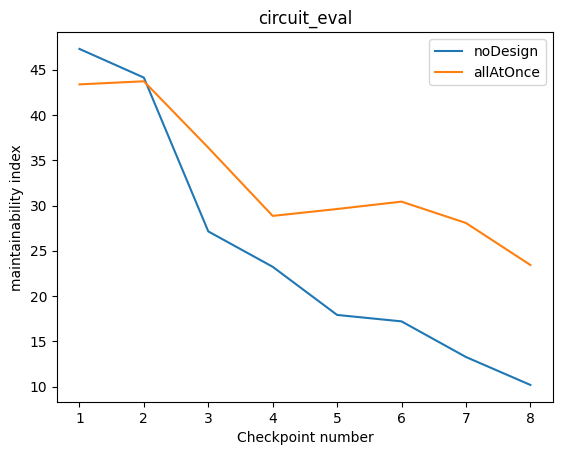

In [20]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    plt.plot(x, entry, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("maintainability index")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## For each of the directories generate temporary dirs for metrics

In [4]:
import subprocess 
import shutil 

for i, dir in enumerate(dirs):  
    subprocess.run([
        "scripts/metrics.sh", 
        dir, 
        f"temp_metrics/{modes[i]}"
    ], check=True)

[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/agent_workspace_noDesign/implementation
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/noDesign/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_131520_1782941956_877571/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/noDesign/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 755	Number of packages: 1
	Number of classes: 33	Number of modules: 1
	number of methods/functions: 67
-Total architecture smell instances detected-
	God component: 0	Unstable dependen

## Lines of code

In [10]:
import json 
from collections import defaultdict

for mode in modes: 
    # store modules: lines of code 
    d = defaultdict(int) 

    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        for f in function_metrics: 
            d[f["Module"]] += f["LOC"]
    
    print(json.dumps(d, indent=2))

{
  "circopt": 706
}
{
  "circopt_reporting": 46,
  "circopt_values": 67,
  "circopt_operator_semantics": 75,
  "circopt_model": 21,
  "circopt_evaluator": 41,
  "circopt_parser": 194,
  "circopt_input_binding": 32,
  "circopt": 2,
  "circopt_validator": 108,
  "circopt_cli": 165,
  "circopt_errors": 20
}
{
  "circ_parser": 194,
  "bit_values": 69,
  "circ_model": 27,
  "evaluator": 96,
  "commands": 14,
  "validator": 247,
  "runtime_inputs": 28,
  "circopt": 2,
  "errors": 7,
  "output": 55,
  "cli": 119
}


## Cyclomatic complexity

In [12]:
for mode in modes: 
    # store modules: lines of code 
    function_total = 0 
    cc_5 = 0 
    cc_10 = 0 

    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        function_total = len(function_metrics) 
        for f in function_metrics: 
            if f["CC"] >= 5: 
                cc_5 += 1 
            if f["CC"] >= 10: 
                cc_10 += 1 
        
        print(f"""Total no. of functions: {function_total} 
No. of functions CC>=5: {cc_5} 
No. of functions CC>=10: {cc_10}
""")

Total no. of functions: 67 
No. of functions CC>=5: 11 
No. of functions CC>=10: 2

Total no. of functions: 88 
No. of functions CC>=5: 8 
No. of functions CC>=10: 0

Total no. of functions: 93 
No. of functions CC>=5: 7 
No. of functions CC>=10: 0



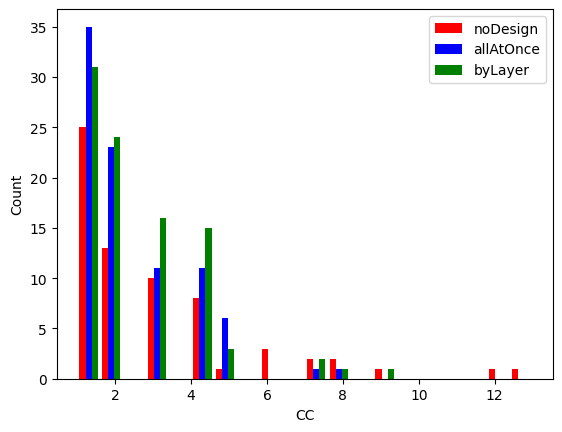

In [17]:
# Histogram of CC 
import matplotlib.pyplot as plt 

data = [] 
for mode in modes: 
    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        data.append(
            [x["CC"] for x in function_metrics]
        )

plt.hist(
    data,
    bins=20,
    label=modes,
    color=["red", "blue", "green"]
)

plt.legend()
plt.xlabel("CC")
plt.ylabel("Count")
plt.show()